<a href="https://colab.research.google.com/github/DinaKSari/PCVK_2026_2027/blob/main/week7_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
NAMA = 'DINA KUMALA SARI'
NIM  = '244107020072'
print(NAMA, NIM)

DINA KUMALA SARI 244107020072


In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from google.colab.patches import cv2_imshow

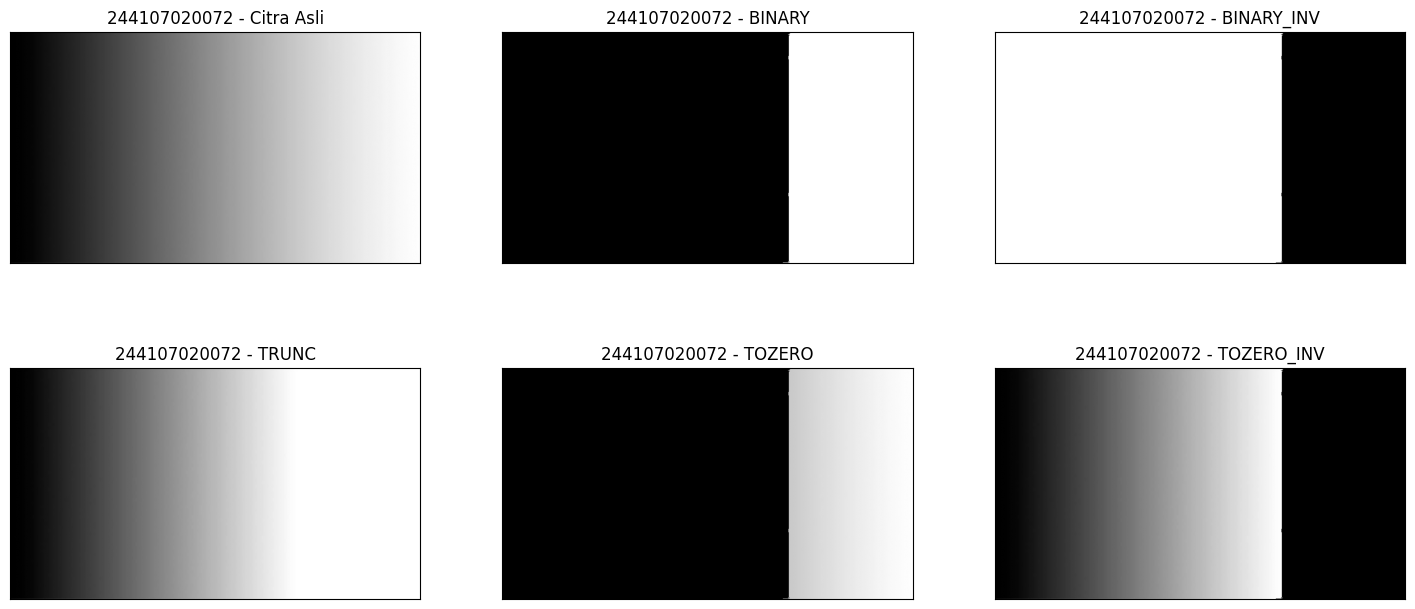

In [56]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/gradient.jpg', 0)
thresh = 200
maxval = 255

binary       = np.where(img > thresh, maxval, 0).astype(np.uint8)
binary_inv   = np.where(img > thresh, 0, maxval).astype(np.uint8)
trunc        = np.where(img > thresh, thresh, img).astype(np.uint8)
tozero       = np.where(img > thresh, img, 0).astype(np.uint8)
tozero_inv   = np.where(img > thresh, 0, img).astype(np.uint8)

titles = ['Citra Asli', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
citra = [img, binary, binary_inv, trunc, tozero, tozero_inv]

plt.figure(figsize=(18,8))
for i in range(len(citra)):
    plt.subplot(2,3,i+1)
    plt.imshow(citra[i], 'gray')
    plt.title(NIM + ' - ' + titles[i])
    plt.xticks([]); plt.yticks([])
plt.show()

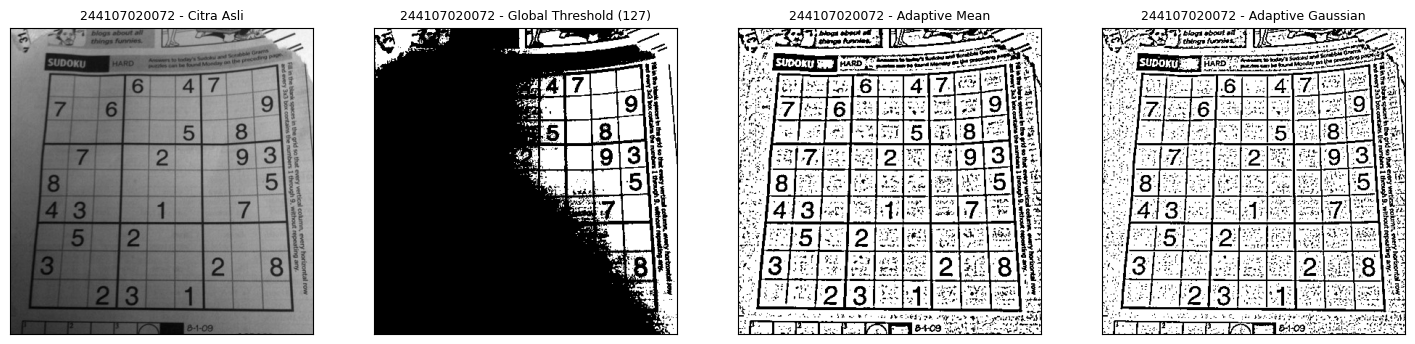

In [57]:
sudoku = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/sudoku-original.jpg', 0)

def adaptive_mean(gray, window=11, C=2):
    pad = window // 2
    padded = np.pad(gray.astype(np.float64), pad, mode='reflect')
    out = np.zeros_like(gray, dtype=np.uint8)
    H, W = gray.shape
    for y in range(H):
        for x in range(W):
            region = padded[y:y+window, x:x+window]
            T = region.mean() - C
            out[y, x] = 255 if gray[y, x] > T else 0
    return out

def gaussian_weight(window, sigma):
    ax = np.arange(window) - window // 2
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / kernel.sum()

def adaptive_gaussian(gray, window=11, C=2, sigma=2):
    pad = window // 2
    padded = np.pad(gray.astype(np.float64), pad, mode='reflect')
    weight = gaussian_weight(window, sigma)
    out = np.zeros_like(gray, dtype=np.uint8)
    H, W = gray.shape
    for y in range(H):
        for x in range(W):
            region = padded[y:y+window, x:x+window]
            T = np.sum(region * weight) - C
            out[y, x] = 255 if gray[y, x] > T else 0
    return out

_, global_th = cv.threshold(sudoku, 127, 255, cv.THRESH_BINARY)
mean_th = adaptive_mean(sudoku, window=11, C=2)
gauss_th = adaptive_gaussian(sudoku, window=11, C=2, sigma=2)

titles = ['Citra Asli', 'Global Threshold (127)', 'Adaptive Mean', 'Adaptive Gaussian']
citra = [sudoku, global_th, mean_th, gauss_th]

plt.figure(figsize=(18,5))
for i in range(len(citra)):
    plt.subplot(1,4,i+1)
    plt.imshow(citra[i], 'gray')
    plt.title(NIM + ' - ' + titles[i], fontsize=9)
    plt.xticks([]); plt.yticks([])
plt.show()

/tmp/ipykernel_4516/2044827153.py:19: RuntimeWarning: invalid value encountered in divide
  mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)


132


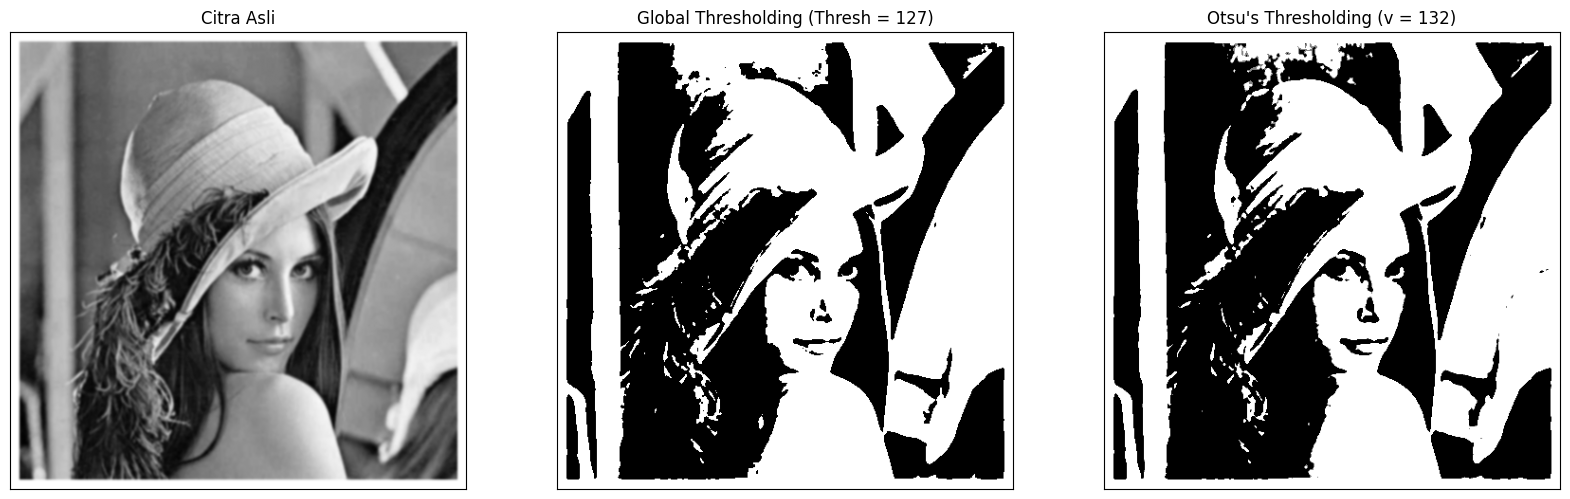

In [58]:
filename = '/content/drive/MyDrive/PCVK/Images/244107020072/lena_gs_lc2.png'
img = cv.imread(filename, 0)
blur = cv.GaussianBlur(img, (5,5), 0)
thresh = 127

def otsu(gray):
    pixel_number = gray.shape[0] * gray.shape[1]
    mean_weight = 1.0/pixel_number
    his, bins = np.histogram(gray, np.arange(0,257))
    final_thresh = -1
    final_value = -1
    intensity_arr = np.arange(256)
    for t in bins[1:-1]:
        pcb = np.sum(his[:t])
        pcf = np.sum(his[t:])
        Wb = pcb * mean_weight
        Wf = pcf * mean_weight

        mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)
        muf = np.sum(intensity_arr[t:]*his[t:]) / float(pcf)
        value = Wb * Wf * (mub - muf) ** 2

        if value > final_value:
            final_thresh = t
            final_value = value
    final_img = gray.copy()
    print(final_thresh)
    final_img[gray > final_thresh] = 255
    final_img[gray < final_thresh] = 0
    return final_img, final_thresh

otsu_biner, otsu_thresh = otsu(blur)
x = ("Otsu's Thresholding (v = ")+str(otsu_thresh)+")"
ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)

titles = ['Citra Asli', 'Global Thresholding (Thresh = ' + str(thresh) +
')', x]
citra3 = [blur, th1, otsu_biner]

plt.figure(figsize = (20,15))
for i in range(len(citra3)):
    plt.subplot(1,3,i+1),plt.imshow(citra3[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

/tmp/ipykernel_4516/2044827153.py:19: RuntimeWarning: invalid value encountered in divide
  mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)


166


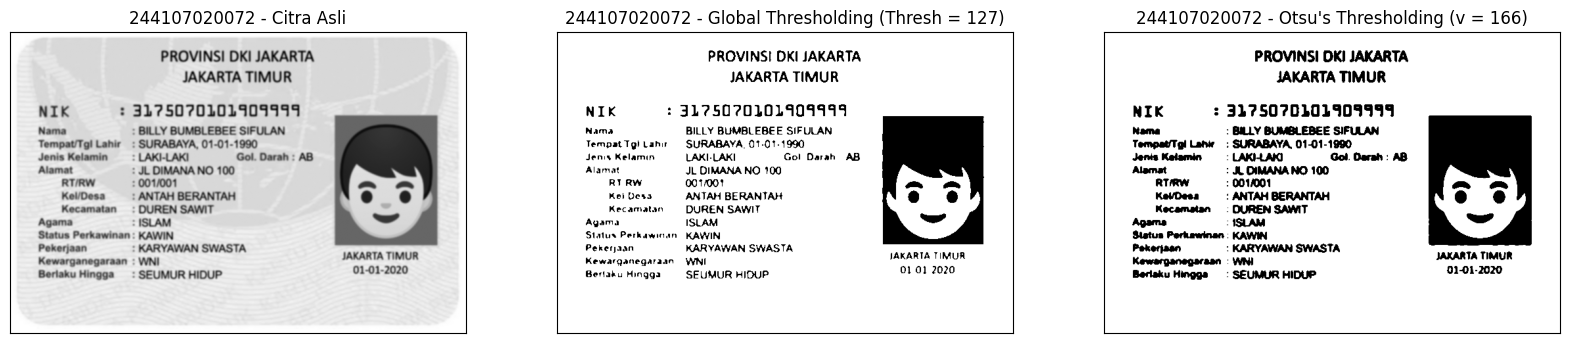

In [59]:
filename_ktp = '/content/drive/MyDrive/PCVK/Images/244107020072/ktp_fulan.jpg'
img_ktp = cv.imread(filename_ktp, 0)
blur_ktp = cv.GaussianBlur(img_ktp, (5,5), 0)
thresh = 127

otsu_biner_ktp, otsu_thresh_ktp = otsu(blur_ktp)
x_ktp = ("Otsu's Thresholding (v = ") + str(otsu_thresh_ktp) + ")"
ret, th1_ktp = cv.threshold(blur_ktp, thresh, 255, cv.THRESH_BINARY)

titles = ['Citra Asli', 'Global Thresholding (Thresh = ' + str(thresh) + ')', x_ktp]
citra3_ktp = [blur_ktp, th1_ktp, otsu_biner_ktp]

plt.figure(figsize=(20,15))
for i in range(len(citra3_ktp)):
    plt.subplot(1,3,i+1), plt.imshow(citra3_ktp[i], 'gray')
    plt.title(NIM + ' - ' + titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

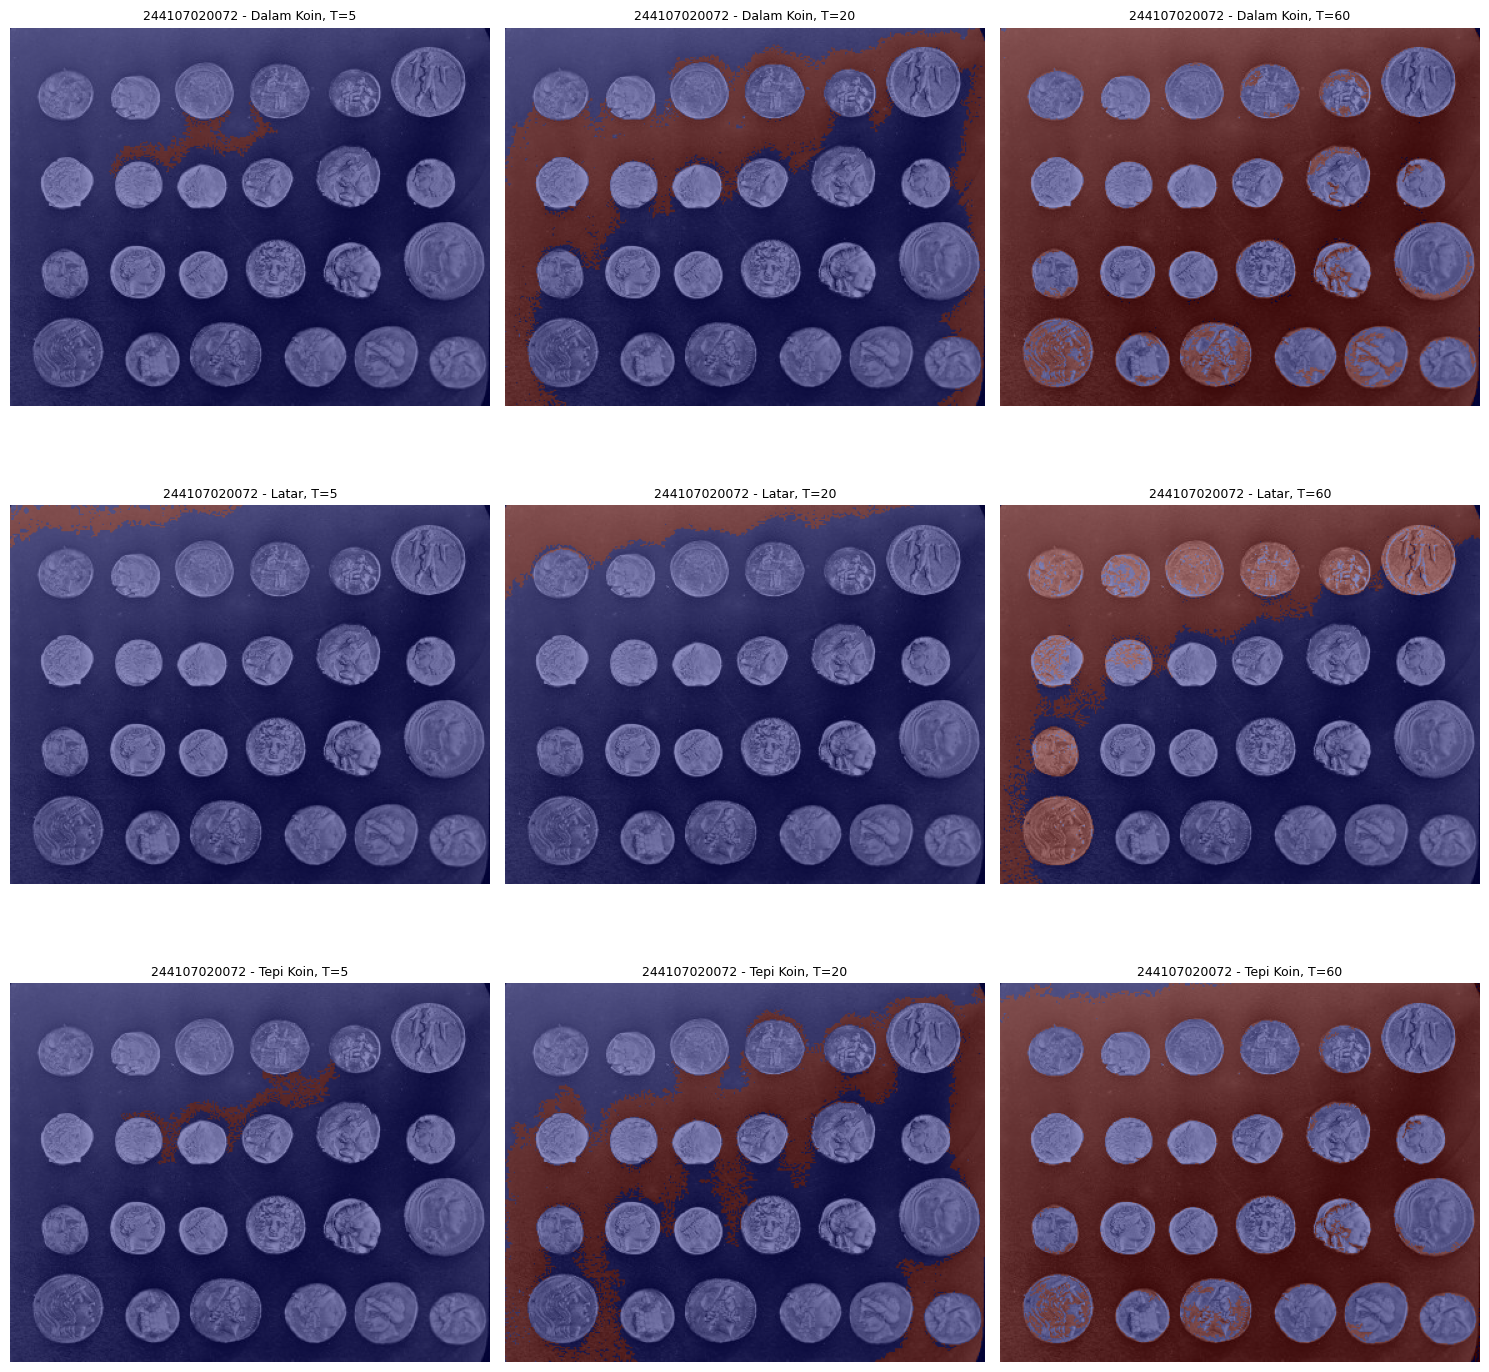

In [60]:
from skimage import data
from skimage.segmentation import flood

coins = data.coins()

# 3 seed: dalam koin, latar, tepi koin
seeds = {'Dalam Koin': (100, 100), 'Latar': (10, 10), 'Tepi Koin': (100, 150)}
T_values = [5, 20, 60]

plt.figure(figsize=(15,15))
idx = 1
for seed_name, seed_point in seeds.items():
    for T in T_values:
        mask = flood(coins, seed_point, tolerance=T)
        plt.subplot(3, 3, idx)
        plt.imshow(coins, cmap='gray')
        plt.imshow(mask, cmap='jet', alpha=0.4)
        plt.title(NIM + f' - {seed_name}, T={T}', fontsize=9)
        plt.axis('off')
        idx += 1
plt.tight_layout()
plt.show()

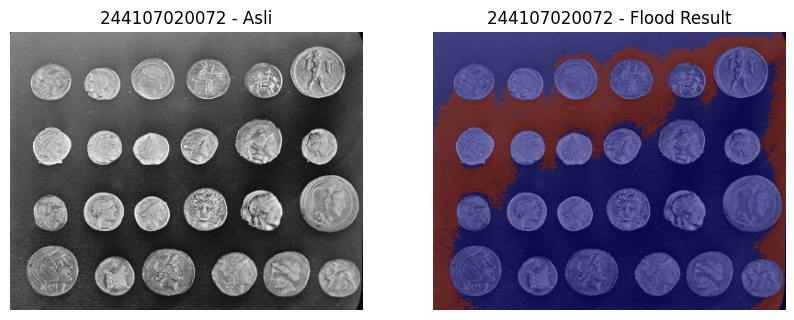

In [61]:
from skimage.segmentation import flood

seed_point = (100, 100)
mask_flood = flood(coins, seed_point, tolerance=20)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(coins, cmap='gray'); plt.title(NIM + ' - Asli'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(coins, cmap='gray'); plt.imshow(mask_flood, cmap='jet', alpha=0.5)
plt.title(NIM + ' - Flood Result'); plt.axis('off')
plt.show()

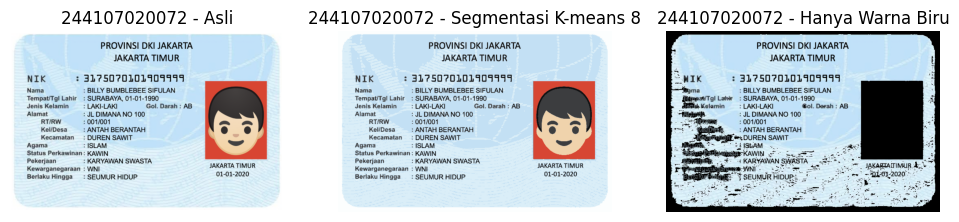

In [62]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ktp = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/ktp_fulan.jpg')
hsv = cv.cvtColor(ktp, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

kelompok_biru = np.where((H >= 85) & (H <= 130) & (S >= 25) & (V >= 40))

mask_biru = np.zeros(H.shape, dtype=np.uint8)
mask_biru[kelompok_biru] = 255
#k means
filename = ('/content/drive/MyDrive/PCVK/Images/244107020072/ktp_fulan.jpg')
img = cv.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Ubah citra menjadi array 2D (piksel)
Z = img.reshape((-1, 3))
Z = np.float32(Z)
# Tentukan jumlah cluster
k = 8
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(Z)
# Dapatkan label dan pusat cluster
labels = kmeans.labels_
centers = np.uint8(kmeans.cluster_centers_)
# Bentuk citra hasil segmentasi
segmented = centers[labels.flatten()]
segmented_img = segmented.reshape(img.shape)

hasil_biru = cv.bitwise_and(ktp, ktp, mask=mask_biru)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(cv.cvtColor(ktp, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Asli'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(segmented_img); plt.title(NIM + ' - Segmentasi K-means 8'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(cv.cvtColor(hasil_biru, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Hanya Warna Biru'); plt.axis('off')
plt.show()

# Kerja Kelompok
Instruksi pengerjaan:
1. Siapkan tiga citra untuk dibandingkan:
- Citra berwarna asli.
- Citra hasil segmentasi menggunakan Otsu Thresholding.
- Citra hasil segmentasi menggunakan Adaptive Thresholding.
Gunakan ukuran citra yang sama. Untuk kedua metode thresholding, ubah citra menjadi
grayscale terlebih dahulu.
2. Lakukan pembacaan teks pada ketiga citra menggunakan pytesseract.image_to_string().
Gunakan bahasa dan pengaturan --psm yang sama agar perbandingan konsisten.
3. Tampilkan area teks yang dikenali menggunakan pytesseract.image_to_data() dan kotak
hijau. Gunakan batas confidence yang sama, misalnya lebih dari 60, pada ketiga citra.
4. Bandingkan hasil pembacaan dengan tulisan sebenarnya pada gambar. Pilih 10 kata atau
angka yang terlihat jelas sebagai acuan, lalu isi tabel berikut. Penilaian dilakukan pada teks
hasil OCR, bukan hanya pada kata yang diberi kotak.
5. Hitung persentase kecocokan untuk setiap metode. Hasil dinyatakan cocok jika seluruh huruf
atau angka pada item sama dengan acuan; abaikan perbedaan huruf besar dan kecil serta
spasi di awal/akhir.
Item yang tidak terbaca dihitung sebagai tidak cocok. Lengkapi ringkasan berikut:

In [63]:
!apt-get install -y tesseract-ocr tesseract-ocr-ind > /dev/null
!pip install pytesseract > /dev/null

In [67]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pytesseract
from google.colab import drive
drive.mount('/content/drive')

NAMA = 'DINA KUMALA SARI'
NIM  = '244107020072'

BASE = '/content/drive/MyDrive/PCVK/Images/244107020072/'
anggota = ['dina', 'eril', 'raya', 'yahya']
LEBAR = 1000
CONFIG = '--psm 6'
LANG = 'ind'
CONF_MIN = 60

def siapkan(nama):
    bgr = cv.imread(BASE + 'ktm-' + nama + '.jpg')
    h, w = bgr.shape[:2]
    bgr = cv.resize(bgr, (LEBAR, int(h * LEBAR / w)))
    gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    _, otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    adaptive = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv.THRESH_BINARY, 31, 10)
    return {'BERWARNA': bgr, 'OTSU': otsu, 'ADAPTIVE': adaptive}

data = {n: siapkan(n) for n in anggota}

# Tampilkan tiga citra untuk dibandingkan
for n in anggota:
    plt.figure(figsize=(18,5))
    for i, (k, c) in enumerate(data[n].items(), 1):
        plt.subplot(1,3,i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB) if c.ndim == 3 else c, cmap='gray')
        plt.title(NIM + ' - ' + n.upper() + ' - ' + k)
        plt.axis('off')
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
hasil_teks = {}
for n in anggota:
    print('#' * 20, n.upper(), '#' * 20)
    hasil_teks[n] = {}
    for k, c in data[n].items():
        teks = pytesseract.image_to_string(c, lang=LANG, config=CONFIG)
        hasil_teks[n][k] = teks
        print('=' * 10, k, '=' * 10)
        print(teks.strip())
        print()

In [ ]:
rata_conf = {}
for n in anggota:
    plt.figure(figsize=(21,7))
    rata_conf[n] = {}
    for i, (k, c) in enumerate(data[n].items(), 1):
        d = pytesseract.image_to_data(c, lang=LANG, config=CONFIG,
                                      output_type=pytesseract.Output.DICT)
        vis = c.copy() if c.ndim == 3 else cv.cvtColor(c, cv.COLOR_GRAY2BGR)
        confs = []
        for j in range(len(d['text'])):
            conf = float(d['conf'][j])
            if conf > CONF_MIN and d['text'][j].strip():
                x, y, w, h = d['left'][j], d['top'][j], d['width'][j], d['height'][j]
                cv.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
                confs.append(conf)
        rata_conf[n][k] = np.mean(confs) if confs else 0
        plt.subplot(1,3,i)
        plt.imshow(cv.cvtColor(vis, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + n.upper() + ' - ' + k + ' (' + str(len(confs)) + ' kata)')
        plt.axis('off')
    plt.show()

print('%-8s %-10s %s' % ('KTM', 'Citra', 'Rata-rata confidence'))
for n in anggota:
    for k in data[n]:
        print('%-8s %-10s %.1f' % (n, k, rata_conf[n][k]))

Pertanyaan analisis:
1. Citra masukan mana yang menghasilkan pembacaan paling tepat? Tunjukkan buktinya dari
tabel.
2. Sebutkan minimal dua kesalahan pembacaan, seperti huruf tertukar, angka salah, atau teks
tidak terbaca.
3. Apakah segmentasi selalu meningkatkan ketepatan OCR? Jelaskan berdasarkan hasil
percobaan.
4. Bagaimana warna atau pola latar belakang memengaruhi pembacaan teks?
5. Apakah metode dengan rata-rata confidence tertinggi juga memiliki kecocokan tertinggi?
